## 1. Load Dataset and Import libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error


X_train = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\train_features.csv')
y_train = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\train_target.csv')
X_val = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_features.csv')
y_val = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_target.csv')
X_test = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\test_features.csv')
y_test = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\test_target.csv')
y_val_orig = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_target_original.csv')



xgb_best_model = joblib.load(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\notebooks\08_forecasting\xgb_best_model.pkl')
lgb_best_model = joblib.load(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\notebooks\08_forecasting\lgb_best_model.pkl')








In [5]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    le = LabelEncoder()
    parts = [X_train[col], X_val[col]]
    if col in X_test.columns:
        parts.append(X_test[col])
    combined = pd.concat(parts, ignore_index=True).astype(str)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col]   = le.transform(X_val[col].astype(str)).astype(np.int32)
    if col in X_test.columns:
        X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} labels -> 0..{len(le.classes_) - 1}")

rest = X_train.select_dtypes(include=["object"]).columns.tolist()
if rest:
    raise ValueError(f"Still has object columns: {rest}")

print(f"\nLabelEncoded {len(object_cols)} cols | "
      f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")


  date: 1684 labels -> 0..1683
  family: 33 labels -> 0..32
  type: 5 labels -> 0..4
  city: 22 labels -> 0..21
  state: 16 labels -> 0..15
  store_family: 1782 labels -> 0..1781

LabelEncoded 6 cols | X_train (2918916, 49) | X_val (55242, 49) | X_test (26730, 49)


## 2. Predictions

In [6]:

lgb_val_pred  = lgb_best_model.predict(X_val)
lgb_test_pred = lgb_best_model.predict(X_test)

xgb_val_pred  = xgb_best_model.predict(X_val)
xgb_test_pred = xgb_best_model.predict(X_test)

[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Warning] Unknown parameter: tree_method


## 3. Weighted Average Ensemble

In [8]:
y_test_orig = pd.DataFrame()
y_test_orig['sales'] = np.expm1(y_test['sales_log'])
weights = [(0.5, 0.5), (0.6, 0.4), (0.7, 0.3)]
# (lgb_weight, xgb_weight)

ensemble_results = []

for lgb_w, xgb_w in weights:
    label = f"LGB{int(lgb_w*10)}-XGB{int(xgb_w*10)}"

    # Blend trên log scale rồi mới inverse transform
    val_blend  = lgb_w * lgb_val_pred  + xgb_w * xgb_val_pred
    test_blend = lgb_w * lgb_test_pred + xgb_w * xgb_test_pred

    val_rmsle = np.sqrt(mean_squared_log_error(
        np.clip(y_val_orig["sales"], 0, None),
        np.clip(np.expm1(val_blend), 0, None)
    ))
    test_rmsle = np.sqrt(mean_squared_log_error(
        np.clip(y_test_orig["sales"], 0, None),
        np.clip(np.expm1(test_blend), 0, None)
    ))

    ensemble_results.append({
        "Weights"   : label,
        "Val RMSLE" : round(val_rmsle, 6),
        "Test RMSLE": round(test_rmsle, 6),
    })
    print(f"{label}: Val={val_rmsle:.6f} | Test={test_rmsle:.6f}")

ensemble_df = pd.DataFrame(ensemble_results)

LGB5-XGB5: Val=0.341422 | Test=0.370576
LGB6-XGB4: Val=0.343707 | Test=0.370867
LGB7-XGB3: Val=0.346074 | Test=0.371276


## 4. Comparison Table: Single Models vs Ensemble

In [10]:
# ── Tổng hợp tất cả approaches ──
summary = pd.DataFrame([
    {"Approach": "LightGBM (tuned)", "Val RMSLE": 0.353654, "Test RMSLE": 0.373215},
    {"Approach": "XGBoost (tuned)",  "Val RMSLE": 0.331299, "Test RMSLE": 0.370917},
    *[{"Approach": f"Ensemble {r['Weights']}", 
       "Val RMSLE": r["Val RMSLE"], 
       "Test RMSLE": r["Test RMSLE"]} 
      for r in ensemble_results]
])

print("\nAll Approaches — Val vs Test RMSLE")
print("=" * 55)
print(summary.to_string(index=False, float_format="{:.6f}".format))
print("=" * 55)

# Best approach theo Test RMSLE
best_row = summary.loc[summary["Test RMSLE"].idxmin()]
print(f"\nBest approach: {best_row['Approach']} (Test RMSLE={best_row['Test RMSLE']:.6f})")


All Approaches — Val vs Test RMSLE
          Approach  Val RMSLE  Test RMSLE
  LightGBM (tuned)   0.353654    0.373215
   XGBoost (tuned)   0.331299    0.370917
Ensemble LGB5-XGB5   0.341422    0.370576
Ensemble LGB6-XGB4   0.343707    0.370867
Ensemble LGB7-XGB3   0.346074    0.371276

Best approach: Ensemble LGB5-XGB5 (Test RMSLE=0.370576)


## 5. Residual Plots

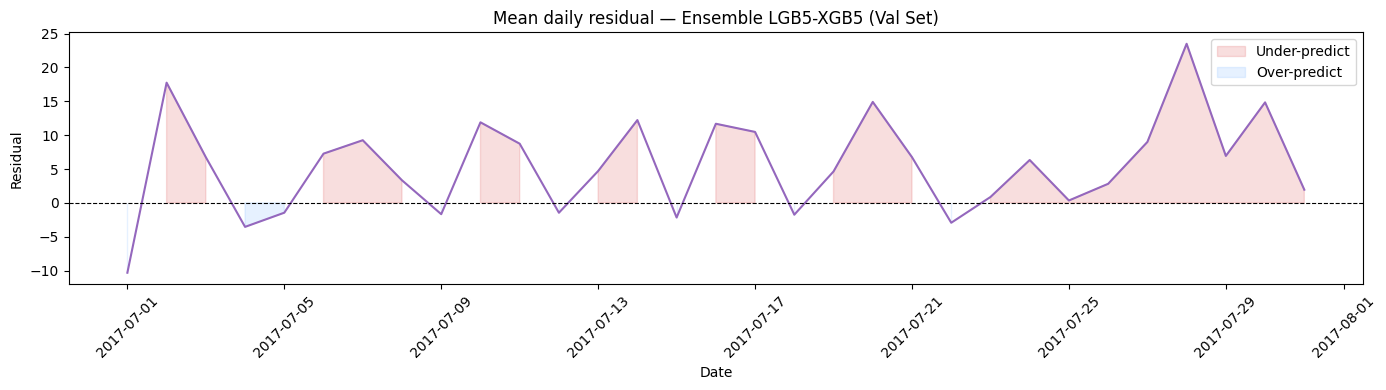

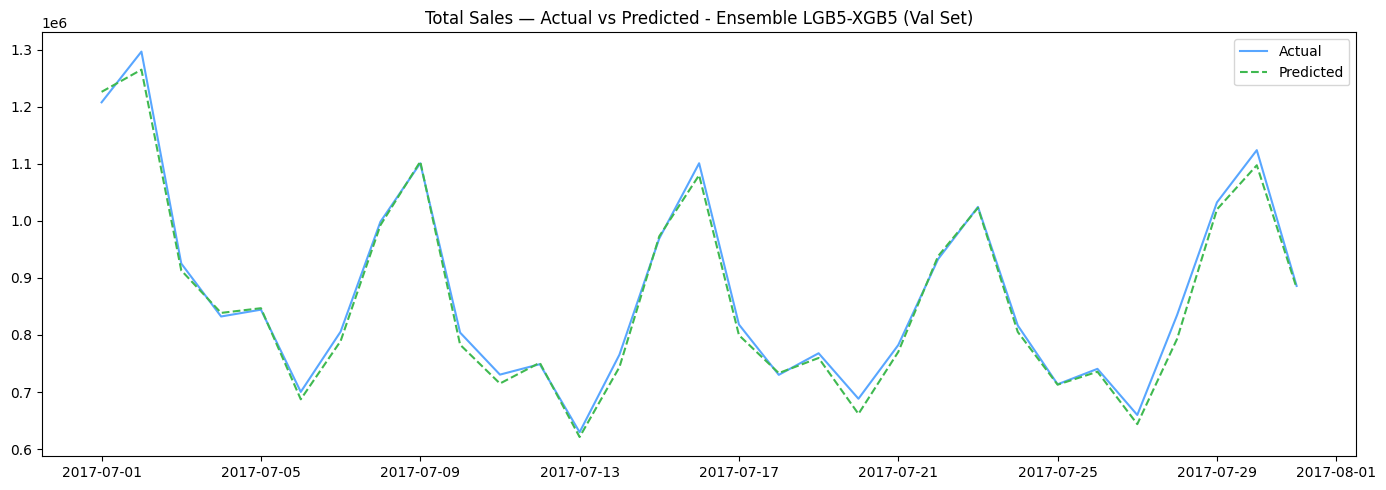

In [15]:
# ── Dùng weight tốt nhất từ kết quả trên ──
best_idx   = ensemble_df["Test RMSLE"].idxmin()
best_lgb_w = float(ensemble_df.iloc[best_idx]["Weights"].split("-")[0].replace("LGB","")) / 10
best_xgb_w = 1 - best_lgb_w

best_val_blend  = best_lgb_w * lgb_val_pred  + best_xgb_w * xgb_val_pred
best_test_blend = best_lgb_w * lgb_test_pred + best_xgb_w * xgb_test_pred



# Residual plot trên val
date_val  = pd.to_datetime(X_val[["year", "month", "day"]])
blend_val_df = pd.DataFrame({
    "date"     : date_val.values,
    "actual"   : y_val_orig["sales"].values,
    "predicted": np.maximum(np.expm1(best_val_blend), 0),
})
blend_val_df["residual"] = blend_val_df["actual"] - blend_val_df["predicted"]

daily_resid = blend_val_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid.index, daily_resid.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values > 0, alpha=0.15, color="#d62728", label="Under-predict")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values < 0, alpha=0.15, color="#58a6ff", label="Over-predict")
ax.set_title(f"Mean daily residual — Ensemble "
             f"LGB{int(best_lgb_w*10)}-XGB{int(best_xgb_w*10)} (Val Set)")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()




# ──  Actual vs Predicted (val) ──
daily_val = blend_val_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_val.index, daily_val["actual"],    label="Actual",    color="#58a6ff")
plt.plot(daily_val.index, daily_val["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title(f"Total Sales — Actual vs Predicted - Ensemble LGB{int(best_lgb_w*10)}-XGB{int(best_xgb_w*10)} (Val Set)")
plt.legend()
plt.tight_layout()
plt.show()

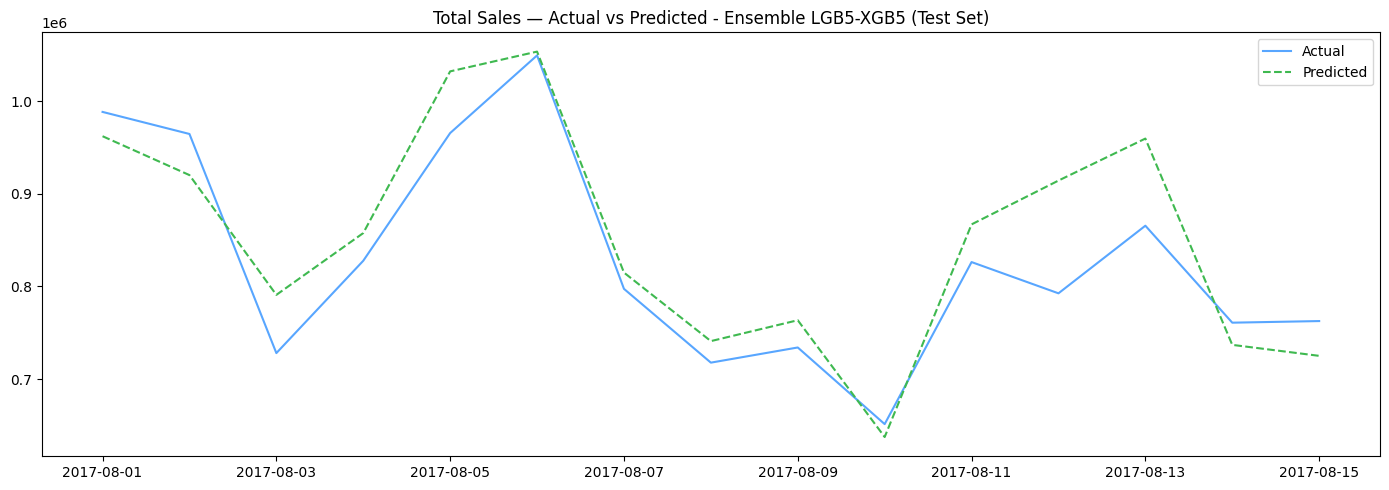

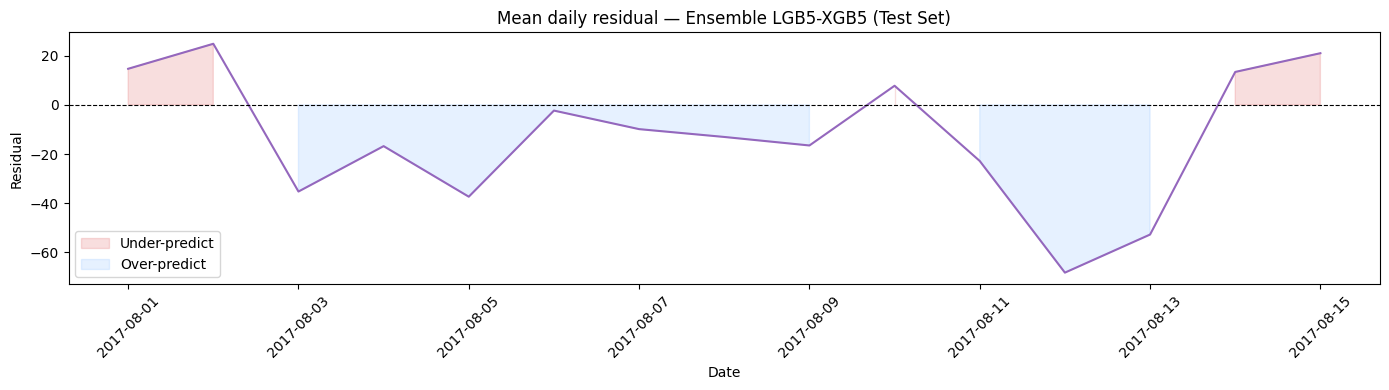

In [13]:
# ── Build test_df từ best blend ──
date_test = pd.to_datetime(X_test[["year", "month", "day"]])

blend_test_df = pd.DataFrame({
    "date"      : date_test.values,
    "actual"    : y_test_orig["sales"].values,
    "predicted" : np.maximum(np.expm1(best_test_blend), 0),
})
blend_test_df["residual"] = blend_test_df["actual"] - blend_test_df["predicted"]

# ── Plot 1: Actual vs Predicted (test) ──
daily_test = blend_test_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_test.index, daily_test["actual"],    label="Actual",    color="#58a6ff")
plt.plot(daily_test.index, daily_test["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title(f"Total Sales — Actual vs Predicted - Ensemble LGB{int(best_lgb_w*10)}-XGB{int(best_xgb_w*10)} (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: Daily residual (test) ──
daily_resid_test = blend_test_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid_test.index, daily_resid_test.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(daily_resid_test.index, daily_resid_test.values, 0,
                where=daily_resid_test.values > 0, alpha=0.15, color="#d62728", label="Under-predict")
ax.fill_between(daily_resid_test.index, daily_resid_test.values, 0,
                where=daily_resid_test.values < 0, alpha=0.15, color="#58a6ff", label="Over-predict")
ax.set_title(f"Mean daily residual — Ensemble LGB{int(best_lgb_w*10)}-XGB{int(best_xgb_w*10)} (Test Set)")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()



In [16]:
holidays = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\raw\holidays_events.csv')
aug_holidays = holidays[
    (holidays['date'] >= '2017-08-01') & 
    (holidays['date'] <= '2017-08-15')
]
print(aug_holidays[['date', 'type', 'locale', 'description', 'transferred']])

           date      type    locale                             description  \
323  2017-08-05   Holiday     Local                 Fundacion de Esmeraldas   
324  2017-08-10   Holiday  National           Primer Grito de Independencia   
325  2017-08-11  Transfer  National  Traslado Primer Grito de Independencia   
326  2017-08-15   Holiday     Local                   Fundacion de Riobamba   

     transferred  
323        False  
324         True  
325        False  
326        False  


In [17]:
# So sánh sales 08-10 đến 08-12 với cùng period năm trước
df = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\train_cleaned.csv')
mask_2017 = (df['date'] >= '2017-08-10') & (df['date'] <= '2017-08-12')
mask_2016 = (df['date'] >= '2016-08-10') & (df['date'] <= '2016-08-12')

print("2017:", df[mask_2017]['sales'].sum())
print("2016:", df[mask_2016]['sales'].sum())

2017: 2270391.1690702
2016: 2000849.2212061002


In [19]:
# Xem feature engineering có xử lý transferred đúng không

# Nếu code chỉ check 'type == Holiday' mà không lọc transferred=True
# thì 08-10 sẽ bị label sai
wrong = holidays[
    (holidays['type'] == 'Holiday') & 
    (holidays['transferred'] == True)
]
print(f"Số holiday bị transferred (label sai): {len(wrong)}")
print(wrong[['date', 'description']].head(10))

Số holiday bị transferred (label sai): 12
           date                    description
19   2012-10-09     Independencia de Guayaquil
72   2013-10-09     Independencia de Guayaquil
135  2014-10-09     Independencia de Guayaquil
255  2016-05-24           Batalla de Pichincha
266  2016-07-25         Fundacion de Guayaquil
268  2016-08-10  Primer Grito de Independencia
297  2017-01-01             Primer dia del ano
303  2017-04-12            Fundacion de Cuenca
312  2017-05-24           Batalla de Pichincha
324  2017-08-10  Primer Grito de Independencia
